In [7]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

zip_path = "/content/drive/MyDrive/Racing Game Hand Gestures.v1-yolov8-640.yolov11.zip"

print("ZIP exists:", os.path.exists(zip_path))

ZIP exists: True


In [9]:
import zipfile

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}  {file}")

dataset/
  data.yaml
  README.roboflow.txt
  README.dataset.txt
  train/
    images/
      IMG20260826232349_jpg.rf.ff97b3c129535352e31df4e1726027b4.jpg
      IMG-20260826-WA0024_jpg.rf.426505f0dedf314667b1cee5263f658d.jpg
      IMG-20260826-WA0059_jpg.rf.4f5b2d7877fd75839566a401921c6a45.jpg
      IMG-20260826-WA0025_jpg.rf.98cbdacc08baa83066432025624826e6.jpg
      IMG-20260826-WA0051_jpg.rf.29b51c300a73f4bdfb6bd5ef1940b807.jpg
    labels/
      IMG-20260826-WA0061_jpg.rf.32648d9e1d345c26b143f18104ee1a4c.txt
      IMG_20260826_232822_jpg.rf.cab4e743e2c5a6ed1a8f90dad9a1c21b.txt
      IMG20260826232645_jpg.rf.fa76b3ecc76d4136a4d7999b1c5671fb.txt
      IMG-20260826-WA0098_jpg.rf.90a2ad291219f0e81c04eb3ba291149c.txt
      IMG-20260826-WA0071_jpg.rf.774b3ddfa607d283851c6fee3ab6f2ea.txt
  valid/
    images/
      IMG-20260826-WA0057_jpg.rf.92ddb3f35094e9b2a0144a6e65339e99.jpg
      IMG_20260826_234606_jpg.rf.c8b4a2830057a7f7ac6d44dbb372e8d8.jpg
      IMG_20260826_232759_jpg.rf.1fc2c447594a4

In [11]:
# Display the dataset configuration

with open("/content/dataset/data.yaml", "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['open palm', 'peace sign']

roboflow:
  workspace: rana-sherif
  project: racing-game-hand-gestures
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/rana-sherif/racing-game-hand-gestures/dataset/1


In [12]:
yaml_content = """
path: /content/dataset

train: train/images
val: valid/images

nc: 2
names:
  0: open palm
  1: peace sign
"""

with open("/content/dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)


path: /content/dataset

train: train/images
val: valid/images

nc: 2
names:
  0: open palm
  1: peace sign



In [13]:
import os

train_images = "/content/dataset/train/images"
train_labels = "/content/dataset/train/labels"

val_images = "/content/dataset/valid/images"
val_labels = "/content/dataset/valid/labels"

print("Train images:", len(os.listdir(train_images)))
print("Train labels:", len(os.listdir(train_labels)))

print("Validation images:", len(os.listdir(val_images)))
print("Validation labels:", len(os.listdir(val_labels)))

Train images: 102
Train labels: 102
Validation images: 27
Validation labels: 27


In [14]:
from glob import glob

label_files = glob("/content/dataset/train/labels/*.txt")

print("Number of label files:", len(label_files))

print("\nExample labels:\n")

for file in label_files[:5]:
    print("File:", os.path.basename(file))

    with open(file, "r") as f:
        print(f.read())

Number of label files: 102

Example labels:

File: IMG-20260826-WA0061_jpg.rf.32648d9e1d345c26b143f18104ee1a4c.txt
0 0.5625 0.4515625 0.57109375 0.52265625
File: IMG_20260826_232822_jpg.rf.cab4e743e2c5a6ed1a8f90dad9a1c21b.txt
0 0.32109375 0.378125 0.35078125 0.7109375
File: IMG20260826232645_jpg.rf.fa76b3ecc76d4136a4d7999b1c5671fb.txt
1 0.66484375 0.4578125 0.2203125 0.3578125
File: IMG-20260826-WA0098_jpg.rf.90a2ad291219f0e81c04eb3ba291149c.txt
1 0.653125 0.30625 0.56640625 0.48359375
File: IMG-20260826-WA0071_jpg.rf.774b3ddfa607d283851c6fee3ab6f2ea.txt
0 0.496875 0.5234375 0.5375 0.24375
0 0.43046875 0.7703125 0.50625 0.37265625


In [15]:
from ultralytics import YOLO

# Load YOLO11 nano model
model = YOLO("yolo11n.pt")

print("YOLO11n loaded successfully!")

YOLO11n loaded successfully!


In [16]:
results = model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=Non

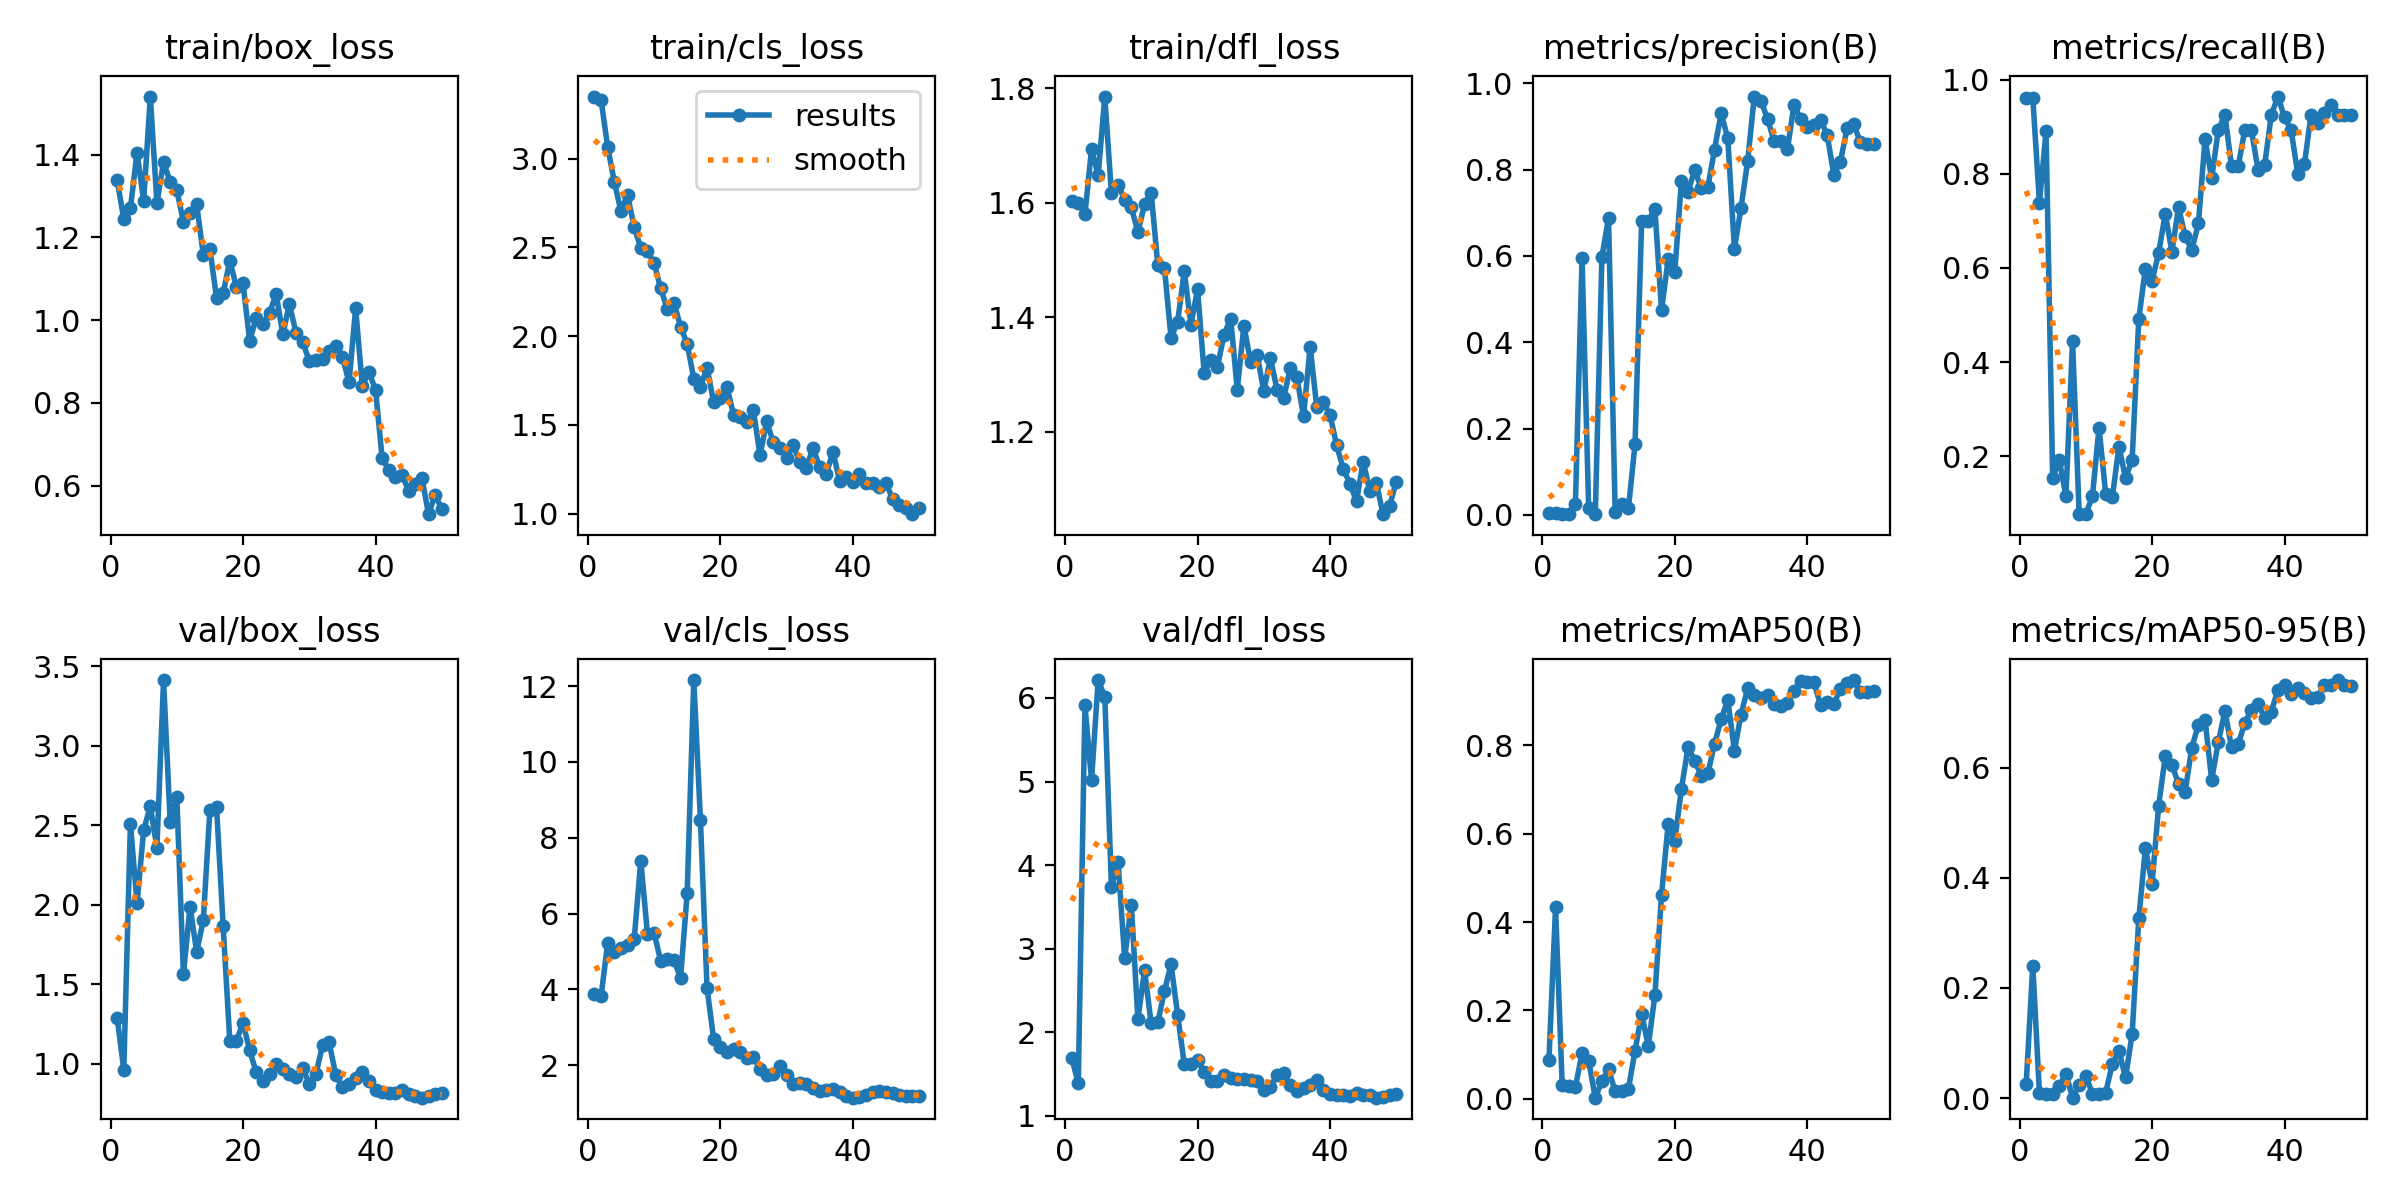

In [17]:
from IPython.display import Image, display

display(Image("/content/runs/detect/train/results.png"))

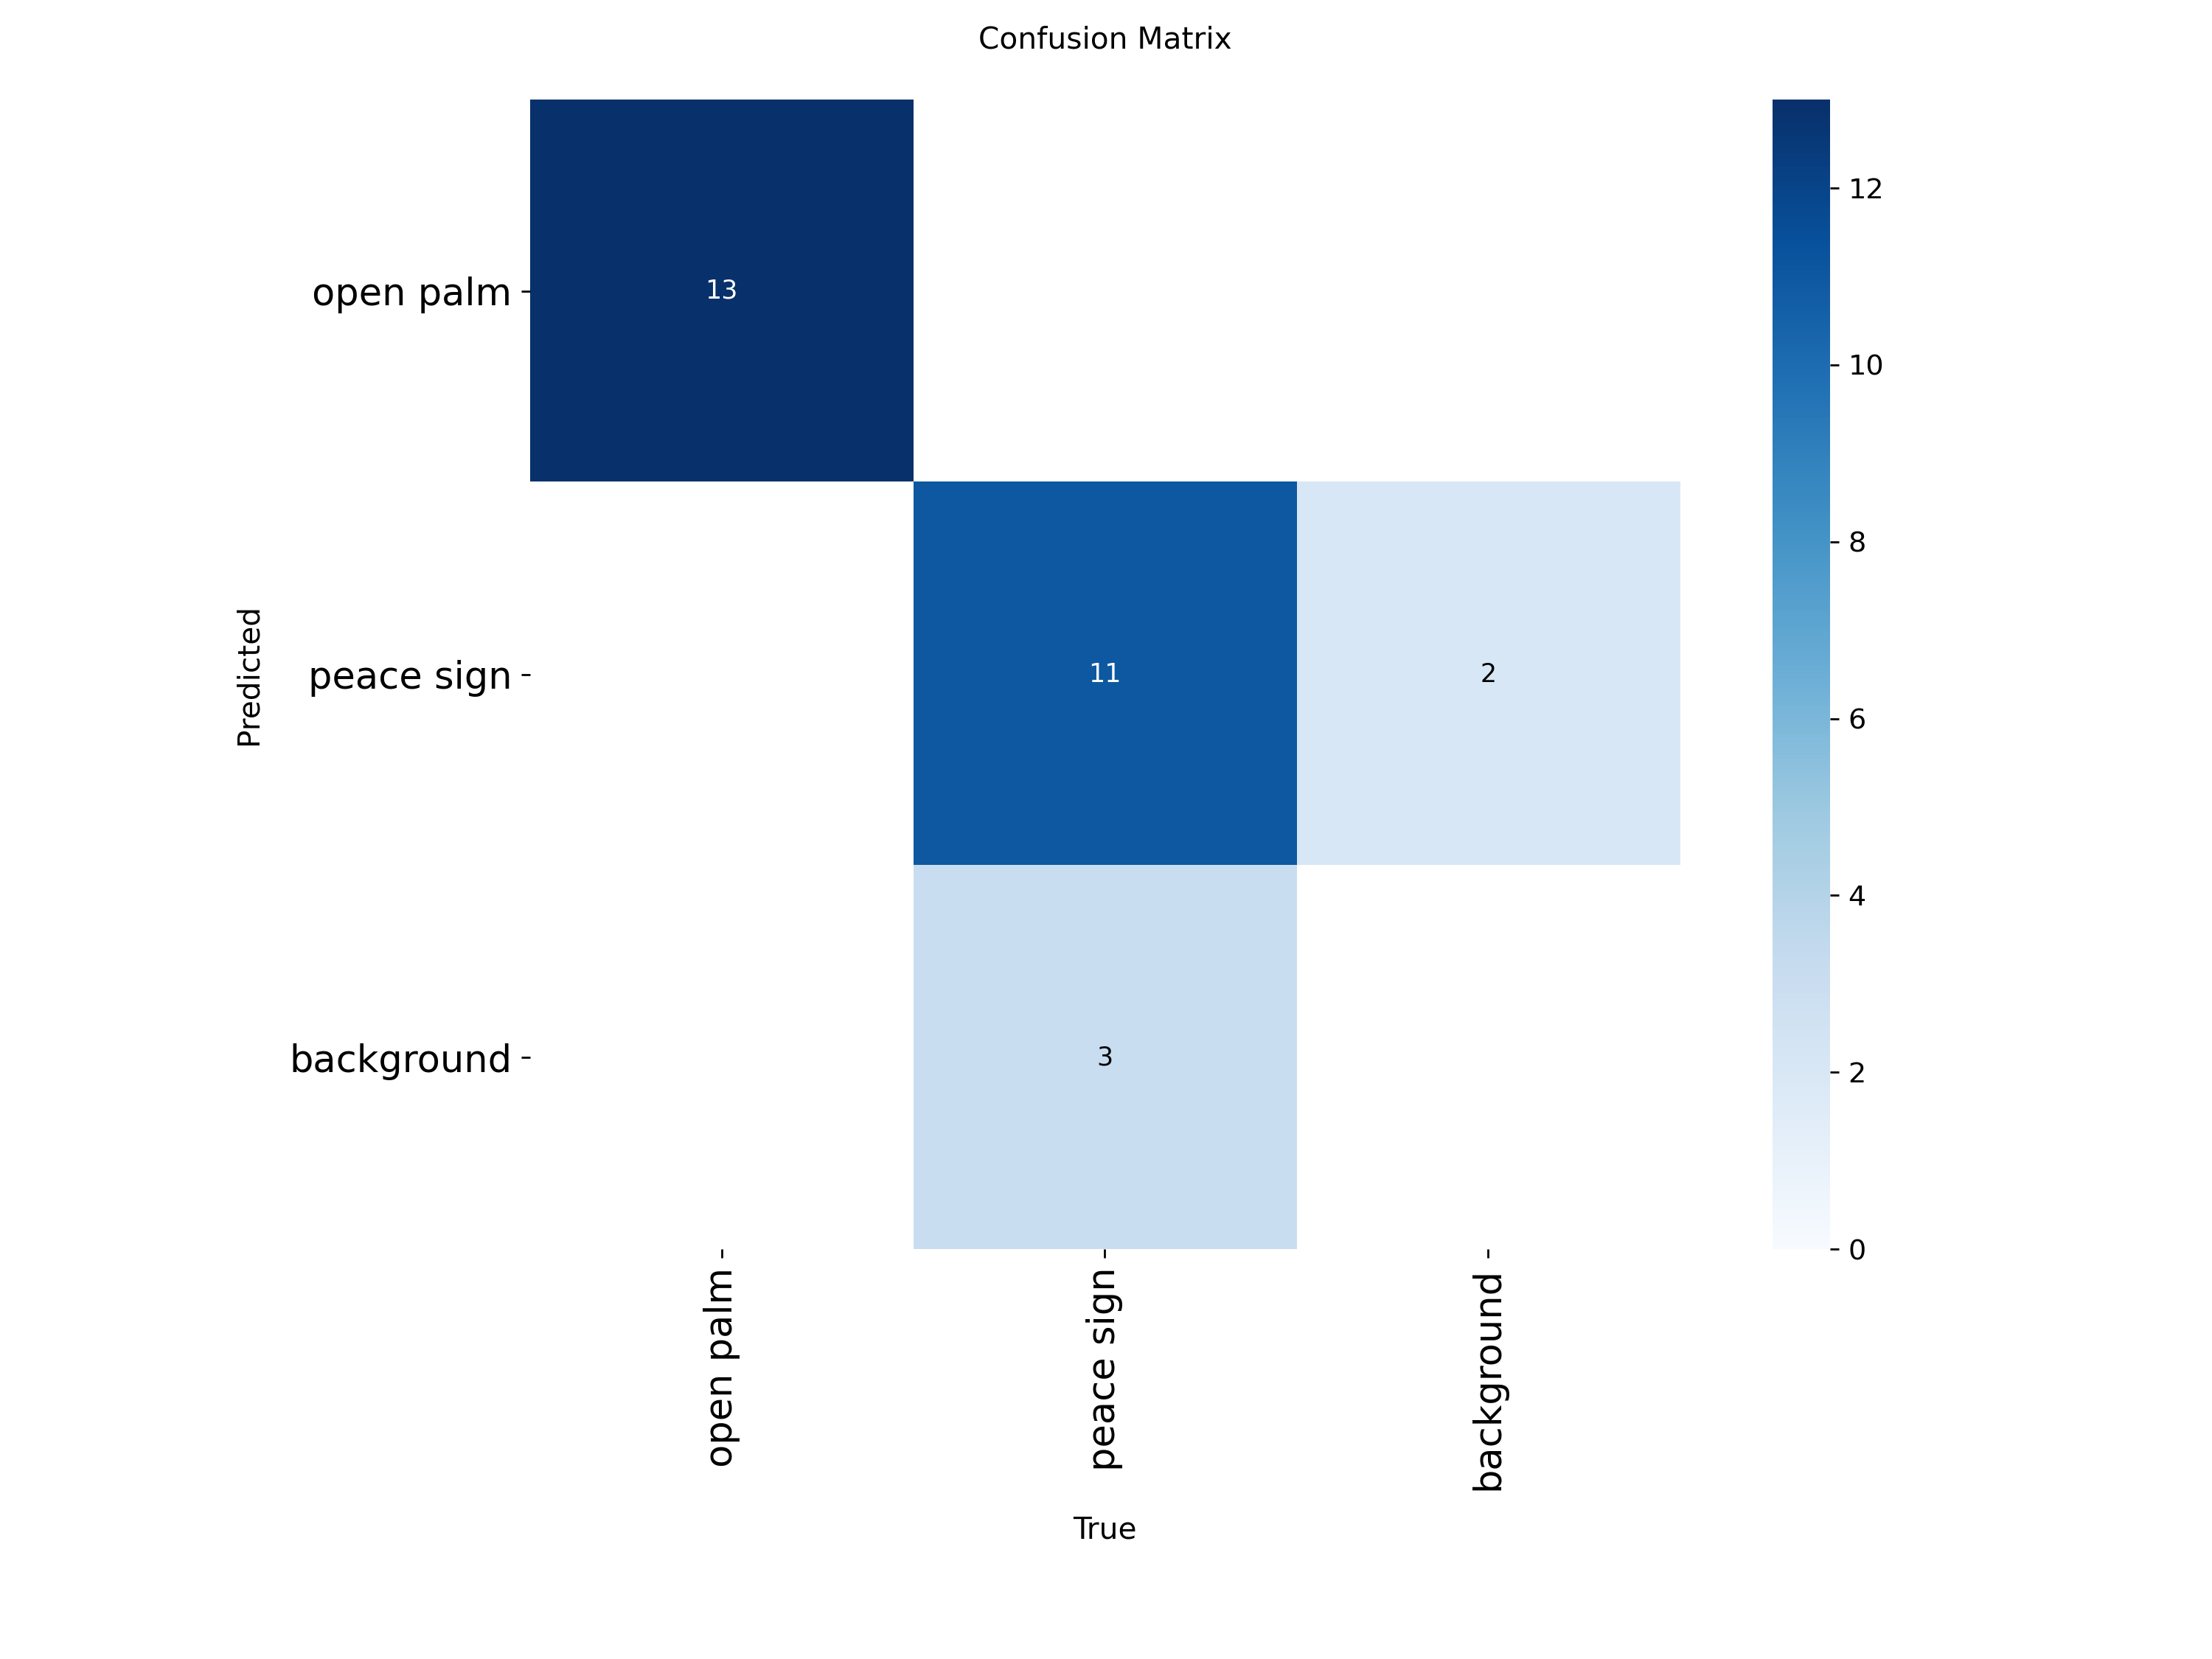

In [18]:
display(Image("/content/runs/detect/train/confusion_matrix.png"))

In [21]:
from google.colab import files

files.download("/content/runs/detect/train/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train/weights/best.pt")

results = best_model.predict(
    source="/content/dataset/valid/images",
    conf=0.5,
    save=True
)

print("Validation images tested successfully!")


image 1/27 /content/dataset/valid/images/IMG-20260826-WA0023_jpg.rf.db144c46fe1bea50f32830531f746da6.jpg: 640x640 1 peace sign, 29.9ms
image 2/27 /content/dataset/valid/images/IMG-20260826-WA0050_jpg.rf.ea9f9b70b31c5bd88441feb5c197171c.jpg: 640x640 1 open palm, 8.8ms
image 3/27 /content/dataset/valid/images/IMG-20260826-WA0052_jpg.rf.19f8d59c30369a004400dca7a8513e4f.jpg: 640x640 1 open palm, 8.0ms
image 4/27 /content/dataset/valid/images/IMG-20260826-WA0057_jpg.rf.92ddb3f35094e9b2a0144a6e65339e99.jpg: 640x640 (no detections), 8.2ms
image 5/27 /content/dataset/valid/images/IMG-20260826-WA0063_jpg.rf.6c7a49382b7d2520503b81707d07a336.jpg: 640x640 1 open palm, 11.9ms
image 6/27 /content/dataset/valid/images/IMG-20260826-WA0075_jpg.rf.d181f503250a31db0c6dcf66bd0339aa.jpg: 640x640 1 open palm, 8.6ms
image 7/27 /content/dataset/valid/images/IMG-20260826-WA0081_jpg.rf.cc8c2e065dca415bdd264d9953332adf.jpg: 640x640 (no detections), 8.5ms
image 8/27 /content/dataset/valid/images/IMG-20260826-WA0

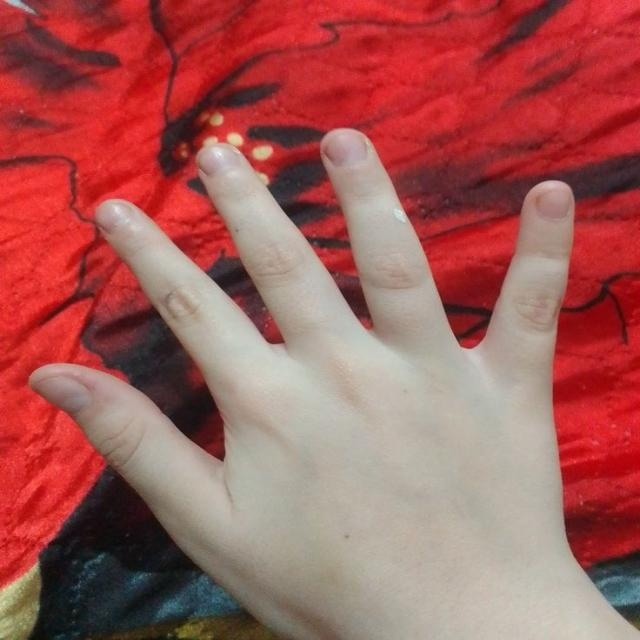

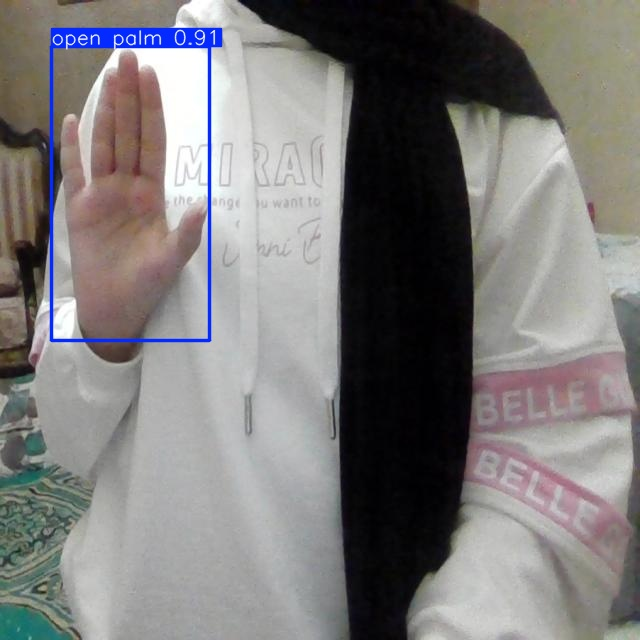

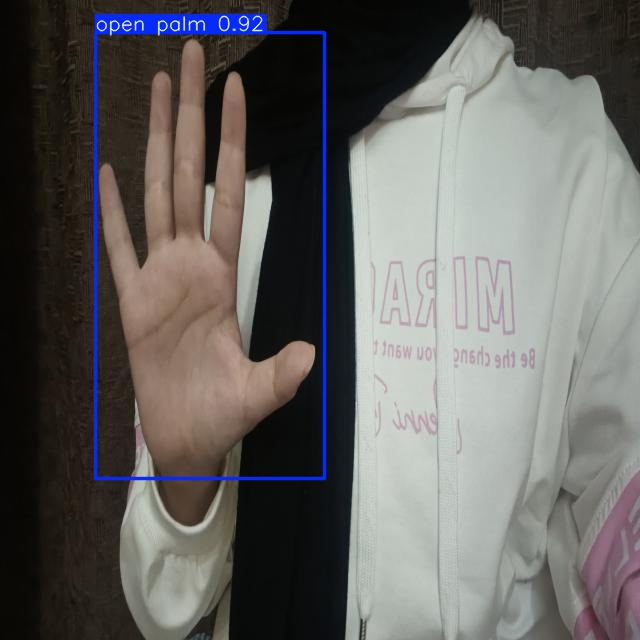

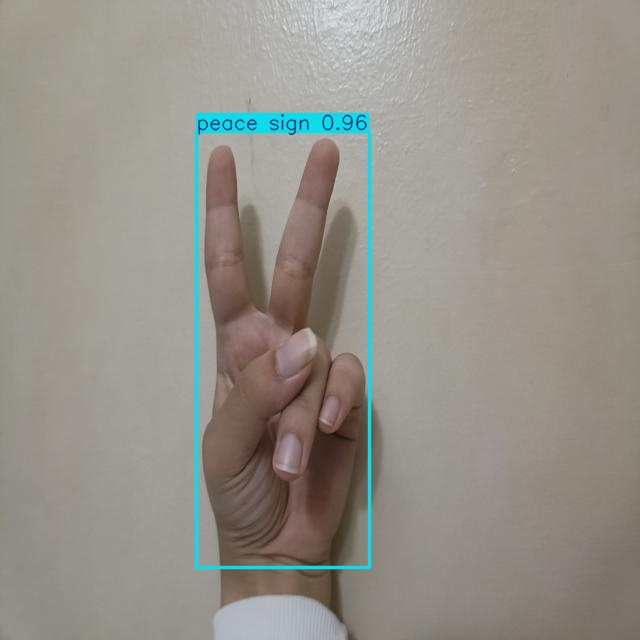

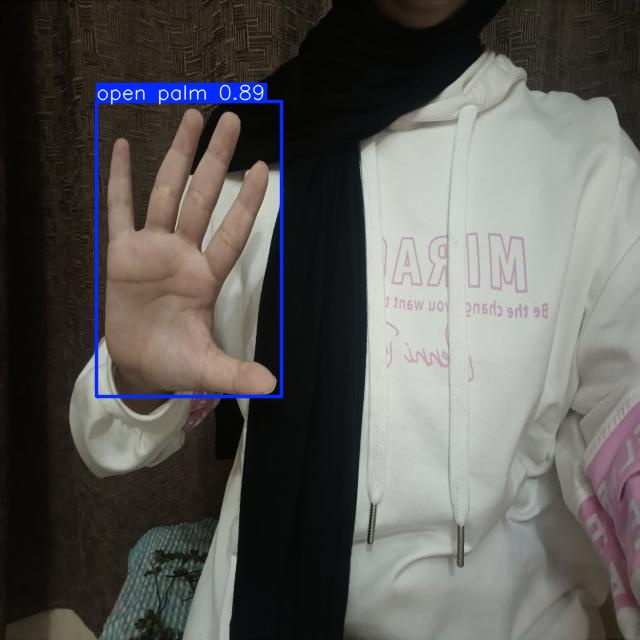

In [20]:
import glob
from IPython.display import Image, display

predicted_images = glob.glob(
    "/content/runs/detect/predict/*.jpg"
)

for img in predicted_images[:5]:
    display(Image(img))

In [22]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train/weights/best.pt")

results = best_model.predict(
    source="/content/dataset/valid/images",
    conf=0.5,
    save=True
)

print("Finished testing all validation images.")


image 1/27 /content/dataset/valid/images/IMG-20260826-WA0023_jpg.rf.db144c46fe1bea50f32830531f746da6.jpg: 640x640 1 peace sign, 9.2ms
image 2/27 /content/dataset/valid/images/IMG-20260826-WA0050_jpg.rf.ea9f9b70b31c5bd88441feb5c197171c.jpg: 640x640 1 open palm, 8.2ms
image 3/27 /content/dataset/valid/images/IMG-20260826-WA0052_jpg.rf.19f8d59c30369a004400dca7a8513e4f.jpg: 640x640 1 open palm, 7.8ms
image 4/27 /content/dataset/valid/images/IMG-20260826-WA0057_jpg.rf.92ddb3f35094e9b2a0144a6e65339e99.jpg: 640x640 (no detections), 8.0ms
image 5/27 /content/dataset/valid/images/IMG-20260826-WA0063_jpg.rf.6c7a49382b7d2520503b81707d07a336.jpg: 640x640 1 open palm, 7.8ms
image 6/27 /content/dataset/valid/images/IMG-20260826-WA0075_jpg.rf.d181f503250a31db0c6dcf66bd0339aa.jpg: 640x640 1 open palm, 8.2ms
image 7/27 /content/dataset/valid/images/IMG-20260826-WA0081_jpg.rf.cc8c2e065dca415bdd264d9953332adf.jpg: 640x640 (no detections), 7.8ms
image 8/27 /content/dataset/valid/images/IMG-20260826-WA008

In [23]:
metrics = best_model.val(
    data="/content/dataset/data.yaml"
)

print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall: {metrics.box.mr:.3f}")
print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 637.2±382.2 MB/s, size: 27.5 KB)
val: Scanning /content/dataset/valid/labels.cache... 27 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 27/27 6.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8it/s 1.1s
                   all         27         27      0.863      0.926       0.92      0.759
             open palm         13         13      0.874      0.923       0.94       0.81
            peace sign         14         14      0.852      0.929        0.9      0.708
Speed: 7.9ms preprocess, 14.3ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /content/runs/detect/val
Precision: 0.863
Recall: 0.926
mAP50: 0.920
mAP50-95: 0.759


In [24]:
import os

best_path = "/content/runs/detect/train/weights/best.pt"

print("Best model exists:", os.path.exists(best_path))
print("Model size:", os.path.getsize(best_path) / (1024 * 1024), "MB")

Best model exists: True
Model size: 5.219751358032227 MB


In [25]:
from google.colab import files

files.download(best_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>